# Cognifyz Intern Task 2: Restaurant Recommendation

## Objective

Create a restaurant recommendation system based on user preferences.

## Steps

1. Preprocess the dataset by handling missing values and encoding categorical variables.
2. Determine the criteria for restaurant recommendation.
3. implement a content-based filtering approach where users are recommended restaurants similar to their perferred criteria.
4. test the recommendation system by providing sample user prefrences and evaluating the quality of recommendations.
5. in 9th Step I Have Keep Test with Sample Users Queries Output Recommedation


# 1 Import Libraries

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

# 2 Load Dataset

In [23]:
df = pd.read_csv(r'D:\Project\cognifyz_projects\dataset\restaurant.csv')

In [24]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [25]:
df.shape

(9551, 21)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [27]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

# 3 Data Cleaning

In [28]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [29]:
df.duplicated().sum()

0

In [30]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [31]:
df['Cuisines'].head(40)

0                     French, Japanese, Desserts
1                                       Japanese
2               Seafood, Asian, Filipino, Indian
3                                Japanese, Sushi
4                               Japanese, Korean
5                                        Chinese
6                                Asian, European
7             Seafood, Filipino, Asian, European
8                        European, Asian, Indian
9                                       Filipino
10                             Filipino, Mexican
11                 American, Ice Cream, Desserts
12                             Filipino, Mexican
13                                      Filipino
14                                        Korean
15             Cafe, American, Italian, Filipino
16                                Italian, Pizza
17                                      Filipino
18                        Cafe, Korean, Desserts
19               Cafe, Bakery, American, Italian
20    Seafood, Ameri

# 4. Exploratory Data Analysis

In [32]:
df["Cuisines"].value_counts().head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

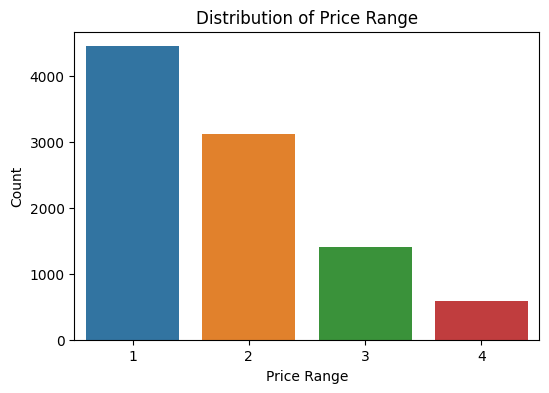

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x="Price range",data=df)

plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Count")

plt.show()

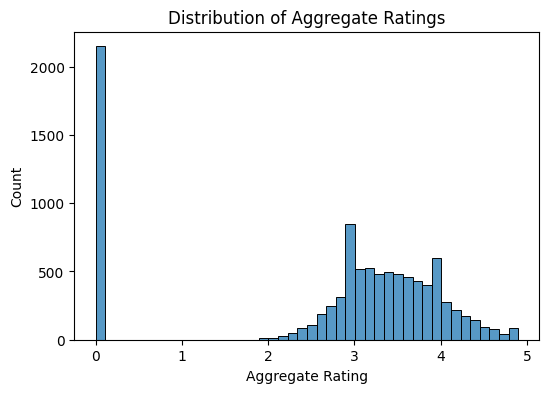

In [34]:
plt.figure(figsize=(6,4))

sns.histplot(df["Aggregate rating"])

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")

plt.show()

# 5. Feature Engineering

In [35]:
df["Features"] = (
    df["Cuisines"].astype(str) + " " +
    df["Price range"].astype(str)
)

# 6. TF-IDF Vectorization


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [37]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["Features"])

# 7. Cosine Similarity Matrix


In [38]:
cosine = cosine_similarity(tfidf_matrix)

# 8. Recommendation Function


In [39]:
def recommend_restaurants(cuisine, price_range, top_n=5):

    user_input = cuisine + " " + str(price_range)

    user_vector = tfidf.transform([user_input])

    similarity = cosine_similarity(
        user_vector,
        tfidf_matrix
    ).flatten()

    top_indices = similarity.argsort()[-top_n:][::-1]

    return df.iloc[top_indices][[
        "Restaurant Name",
        "Cuisines",
        "Price range",
        "Aggregate rating"
    ]]

In [40]:
def recommend_restaurants(cuisine, price_range, top_n=5):

    user_input = cuisine + " " + str(price_range)

    user_vector = tfidf.transform([user_input])

    scores = cosine_similarity(
        user_vector,
        tfidf_matrix
    ).flatten()

    df_temp = df.copy()

    df_temp["Similarity"] = scores

    df_temp = df_temp[
        df_temp["Cuisines"].str.contains(
            cuisine,
            case=False,
            na=False
        )
    ]

    df_temp = df_temp[
        df_temp["Price range"] == price_range
    ]

    df_temp = df_temp[
        df_temp["Aggregate rating"] > 0
    ]

    recommend = df_temp.sort_values(
        by=["Similarity", "Aggregate rating", "Votes"],
        ascending=False
    )

    return recommend.head(top_n)[[
        "Restaurant Name",
        "Cuisines",
        "Price range",
        "Aggregate rating",
        "Votes"
    ]]

# 9. Test with Sample users Output Recommedation.

In [41]:
recommend_restaurants(
    cuisine="North Indian",
    price_range=3
)

,Restaurant Name,Cuisines,Price range,Aggregate rating,Votes
6656,Kopper Kadai,North Indian,3,4.8,83
3014,Zabardast Indian Kitchen,North Indian,3,4.7,242
814,Bombay Brasserie,North Indian,3,4.6,1753
6655,Band Baaja Baaraat,North Indian,3,4.6,128
3999,Rang De Basanti Urban Dhaba,North Indian,3,4.4,541


In [42]:
recommend_restaurants(
    cuisine="Chinese",
    price_range=2
)

,Restaurant Name,Cuisines,Price range,Aggregate rating,Votes
2296,Chung Fa,Chinese,2,4.3,369
9308,Eden Noodles Cafe �__·�_��_��_��,Chinese,2,4.3,212
767,Silver Streak,Chinese,2,4.1,379
7728,Happy Hakka,Chinese,2,4.1,173
199,Chef Lee's Peking Restaurant,Chinese,2,4.0,335


In [43]:
recommend_restaurants(
    cuisine="Cafe",
    price_range=4
)

,Restaurant Name,Cuisines,Price range,Aggregate rating,Votes
623,Crafted Blends,Cafe,4,4.2,43
4959,Longitude - Le Meridien,Cafe,4,3.9,90
7535,Emperor's Lounge - The Taj Mahal Hotel,Cafe,4,3.8,79
4016,Lord William Tea Lounge - Hotel The Royal Plaza,Cafe,4,3.6,38
2186,Citrus Cafe - Lemon Tree Hotel,Cafe,4,2.7,27


# 10. Conclusion

In this project, a content-based restaurant recommendation system was developed using TF-IDF Vectorization and Cosine Similarity. The system recommends restaurants based on user preferences such as cuisine type and price range.

By filtering recommendations using price range and ranking them according to aggregate ratings and votes, the system provides more relevant and high-quality restaurant suggestions. The results demonstrate that content-based filtering is an effective approach for generating personalized restaurant recommendations.